# The Only Winning Move: Eighty Years of Nuclear Arsenals

A data story by Sam Macuga, PSYC 81.09 Storytelling with Data, Dartmouth College, 2026.

**YouTube link:** https://youtu.be/hJDVfCPZOYc

The accompanying video opens with a short clip from the 1983 film *WarGames* and uses the year 1983 as a starting reference point — the bubble chart frame for that year is, as the narration puts it, "a snapshot from 1983, the year *WarGames* came out." The animation then rewinds to 1945 and plays forward through 2026. The video closes with a montage from the end of *WarGames*, where the WOPR computer delivers the film's final line — "The only winning move is not to play" — which the project title draws on. See the *Note on the video* section near the end of the notebook for full media credits.

# Background and overview

**Research question:** What does the data on nuclear arsenals from 1945 to today show, and how does the story differ depending on whether we measure warhead counts or total destructive capacity?

This project investigates eighty years of nuclear arsenals through two metrics: the number of warheads each country held, and the total destructive capacity of those warheads measured in megatons. The two metrics tell related but distinct stories, with peaks years apart and declines driven by different mechanisms.

The film *WarGames* (1983) is referenced in the project title and in the opening of the accompanying video. *WarGames* ended with the line "the only winning move is not to play," at a moment when global stockpiles were near their all-time peak. The bubble chart's 1983 frame — the year the film was released — serves as the visual entry point for the video, before the animation rewinds to 1945 and plays forward through 2026.

# Project team

Sole author: Sam Macuga (Dartmouth College, Storytelling with Data, PSYC 81.09).

# Quick summary of findings

1. **Total destructive capacity peaked years before warhead count peaked.** US megatonnage peaked in 1960 at over 20,000 megatons, seven years before the US warhead count peaked at 32,500 in 1967. Soviet megatonnage peaked in 1975 at 19,400 megatons, ten years before the Soviet warhead count peaked at 45,000 in 1985.

2. **The decline in megatonnage and the decline in warhead counts followed different timelines.** US total megatonnage has been falling almost every year since 1960. US warhead counts began falling in 1967, then dropped sharply after 1986. The same pattern, delayed by about 15 years, holds for the Soviet Union/Russia.

3. **Bilateral arms control treaties limited warhead counts but did not directly limit yield.** SALT, START, SORT, and New START set caps on the number of strategic warheads each country could deploy. None of them directly capped destructive yield. New START, the most recent agreement, expired in February 2026 without a successor.

# Approach

I compiled annual data on warhead counts and total megatonnage for the United States and USSR/Russia from 1945 through 2024 from Johnston's Archive (which reconciles multiple authoritative sources for the historical period) and the Federation of American Scientists Nuclear Notebook for recent years. The visualization is a Plotly animated bubble chart in which each country is a bubble that moves through 2D space over time. Position on the x-axis shows warhead count; position on the y-axis (log scale) shows average yield per warhead; bubble size shows total destructive megatonnage. The supplementary line chart and trajectory figures show the same data from different angles.

# Data

The dataset combines two sources to span 1945 through 2024.

The primary historical source is [Johnston's Archive](https://www.johnstonsarchive.net/nuclear/nukestock.html), specifically:
- [United States, warheads and megatonnage](https://www.johnstonsarchive.net/nuclear/nucstock-1.html), covering 1945-2012
- [USSR/Russia, warheads](https://www.johnstonsarchive.net/nuclear/nucstock-3.html) and [megatonnage](https://www.johnstonsarchive.net/nuclear/nucstock-4.html), covering 1949-2007

Wm. Robert Johnston compiled these estimates by reconciling multiple authoritative sources, including the Natural Resources Defense Council Nuclear Weapons Databook (1984, 1989, 1994, 1995, 2000, 2002, 2006), Department of Energy declassified figures (1994), and reports from senior US defense officials. For each country and year in this period, I use Johnston's own reconciled estimate (his "WRJ" column).

For the years after Johnston's compilation ends — 2013-2024 for the US and 2008-2024 for Russia — I supplement with warhead count estimates from the [Federation of American Scientists Nuclear Notebook](https://thebulletin.org/nuclear-notebook/) and [SIPRI Yearbook 2025](https://www.sipri.org/yearbook/2025/06). For these years, megatonnage is not directly published by either source. I estimate it by extrapolating the average yield per warhead trend from the late Johnston period, accounting for the documented retirement of high-yield weapons (such as the B83-1 in the US arsenal, which is the last megaton-class weapon being phased out).

Each row in the dataset is flagged with its source: `Johnston` for years drawn from Johnston's Archive, and `FAS+estimate` for the supplementary years where warhead counts come from FAS but megatonnage is extrapolated. The recent estimates carry larger uncertainty than the historical ones, but the trends they show are consistent with public statements about ongoing modernization and dismantlement programs.

A note on definitions: "warheads" includes both deployed and stockpiled weapons, but excludes warheads that have been retired and queued for dismantlement. "Megatonnage" represents the total explosive yield of all warheads in the active stockpile, measured in megatons of TNT-equivalent.

In [19]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Plotly handles animated bubble charts natively (the Hans Rosling style)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Ensure plotly renders properly in Colab
pio.renderers.default = 'colab'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## Loading the data

The dataset is provided as a CSV file (`nuclear_yields.csv`) in the project repository. Each row contains one country's estimated warhead count, total megatonnage, and source flag for one year.

In [20]:
# Load the compiled dataset
# Tries the local file first (for repo-cloned projects), falls back to GitHub URL (for Colab)
LOCAL_PATH = 'nuclear_yields.csv'
GITHUB_URL = 'https://raw.githubusercontent.com/smacuga19/storytelling-with-data/master/data-stories/nuclear/nuclear_yields.csv'

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f"Loaded data from local file: {LOCAL_PATH}")
else:
    df = pd.read_csv(GITHUB_URL)
    print(f"Loaded data from GitHub: {GITHUB_URL}")

# Compute average yield per warhead (megatons divided by warheads)
# This is a useful third dimension for the bubble chart
df['avg_yield'] = df['megatons'] / df['warheads']

# Quick sanity check
print(f"\nShape: {df.shape}")
print(f"Countries: {df['country'].unique()}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())

Loaded data from GitHub: https://raw.githubusercontent.com/smacuga19/storytelling-with-data/master/data-stories/nuclear/nuclear_yields.csv

Shape: (156, 6)
Countries: ['United States' 'USSR/Russia']
Year range: 1945 to 2024

First 5 rows:
         country  year  warheads  megatons    source  avg_yield
0  United States  1945         2      0.04  Johnston   0.020000
1  United States  1946         9      0.18  Johnston   0.020000
2  United States  1947        13      0.26  Johnston   0.020000
3  United States  1948        56      1.25  Johnston   0.022321
4    USSR/Russia  1949         1      0.02  Johnston   0.020000


## Confirming the peak years

For each country, we identify the year of maximum warhead count and the year of maximum total megatonnage. The gap between these two values is one of the central observations of the project.

In [21]:
# Find the peak year for each metric, for each country
for country in ['United States', 'USSR/Russia']:
    sub = df[df['country'] == country]

    warhead_peak_year = sub.loc[sub['warheads'].idxmax(), 'year']
    warhead_peak_value = sub['warheads'].max()

    megaton_peak_year = sub.loc[sub['megatons'].idxmax(), 'year']
    megaton_peak_value = sub['megatons'].max()

    gap = warhead_peak_year - megaton_peak_year

    print(f"=== {country} ===")
    print(f"  Warhead count peak:   {warhead_peak_value:>6,} in {warhead_peak_year}")
    print(f"  Megatonnage peak:     {megaton_peak_value:>6,.0f} Mt in {megaton_peak_year}")
    print(f"  Gap:                  {gap} years (megatonnage peaked first)")
    print()

=== United States ===
  Warhead count peak:   32,500 in 1967
  Megatonnage peak:     20,491 Mt in 1960
  Gap:                  7 years (megatonnage peaked first)

=== USSR/Russia ===
  Warhead count peak:   45,000 in 1985
  Megatonnage peak:     19,400 Mt in 1975
  Gap:                  10 years (megatonnage peaked first)



# Analysis

## Figure 1: Warhead counts and megatonnage over time

We start with a static line chart showing both metrics for both countries on a shared x-axis. The two panels share the same time range, so any difference in when each metric peaks is visible at a glance.

/tmp/ipykernel_3755/1132134984.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



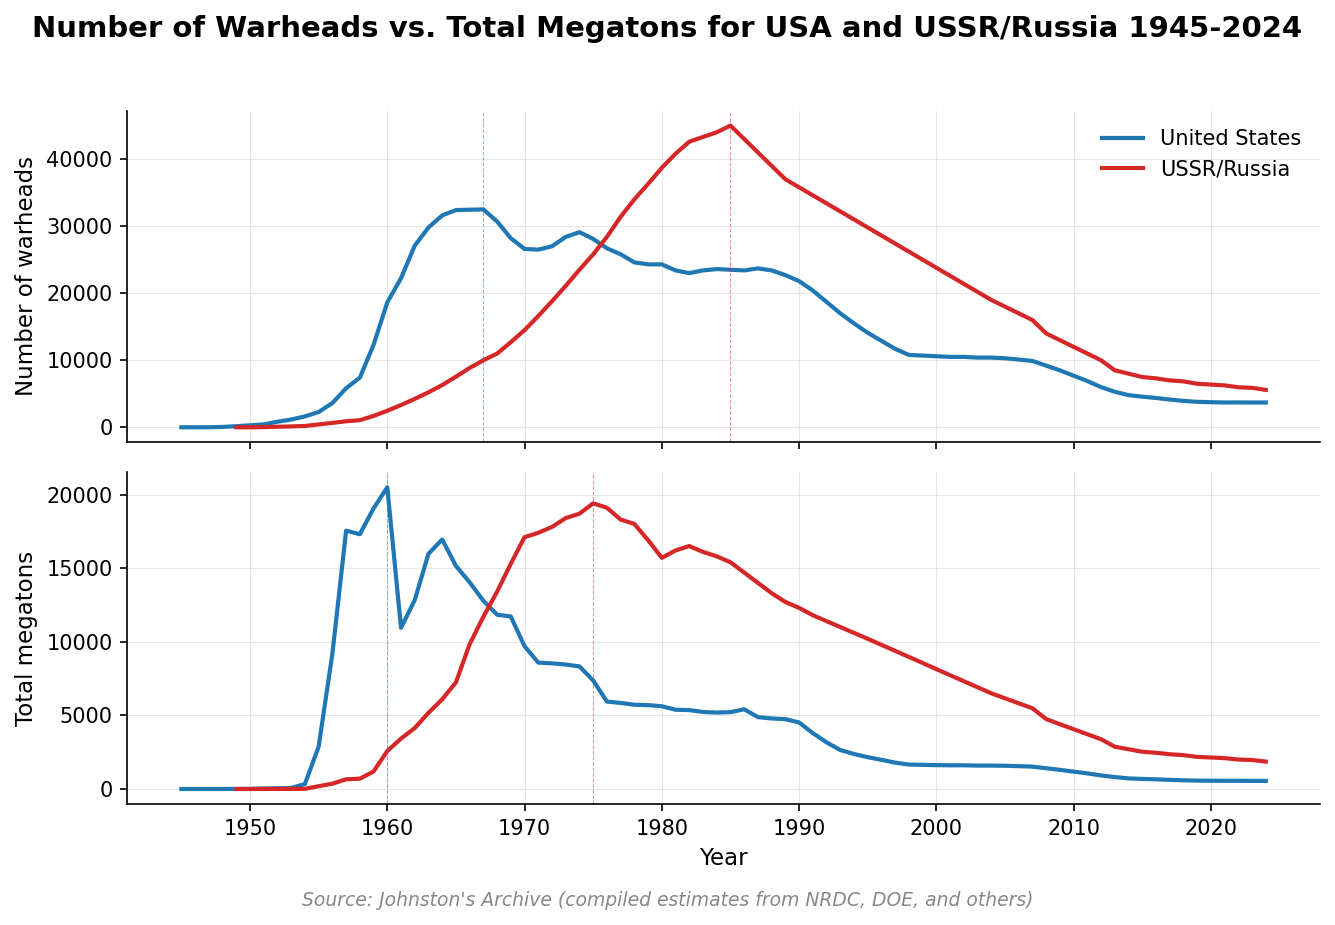

In [22]:
# Two-panel figure: warhead counts on top, megatonnage on bottom
# Same x-axis (year), so the divergence in peak timing is visible

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, dpi=150)
fig.patch.set_facecolor('white')

# Color palette - same as previous nuclear project for consistency
US_COLOR = '#1f77b4'
RU_COLOR = '#d62728'

us = df[df['country'] == 'United States']
ru = df[df['country'] == 'USSR/Russia']

# Top panel: warhead count
ax1.plot(us['year'], us['warheads'], color=US_COLOR, linewidth=2, label='United States')
ax1.plot(ru['year'], ru['warheads'], color=RU_COLOR, linewidth=2, label='USSR/Russia')
ax1.set_ylabel('Number of warheads', fontsize=11)
ax1.legend(loc='upper right', frameon=False)
ax1.grid(True, alpha=0.3, linewidth=0.5)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# Bottom panel: megatonnage
ax2.plot(us['year'], us['megatons'], color=US_COLOR, linewidth=2)
ax2.plot(ru['year'], ru['megatons'], color=RU_COLOR, linewidth=2)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Total megatons', fontsize=11)
ax2.legend(loc='upper right', frameon=False)
ax2.grid(True, alpha=0.3, linewidth=0.5)
ax2.set_axisbelow(True)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Annotate the peaks
for country, color, sub in [('US', US_COLOR, us), ('USSR', RU_COLOR, ru)]:
    # Warhead peak
    wpy = sub.loc[sub['warheads'].idxmax(), 'year']
    wpv = sub['warheads'].max()
    ax1.axvline(wpy, color=color, linewidth=0.5, linestyle='--', alpha=0.5)

    # Megatonnage peak
    mpy = sub.loc[sub['megatons'].idxmax(), 'year']
    mpv = sub['megatons'].max()
    ax2.axvline(mpy, color=color, linewidth=0.5, linestyle='--', alpha=0.5)

# Title for the figure
fig.suptitle('Number of Warheads vs. Total Megatons for USA and USSR/Russia 1945-2024',
             fontsize=14, fontweight='bold', y=0.995)

# Source
fig.text(0.5, 0.005, 'Source: Johnston\'s Archive (compiled estimates from NRDC, DOE, and others)',
         fontsize=9, color='#888888', ha='center', style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('divergence.png', facecolor='white', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2: Hans Rosling-style bubble chart

The line chart shows the divergence between count and megatonnage cleanly. A bubble chart shows it differently — by tracing each country's path through 2D space over time.

Here, the x-axis is warhead count and the y-axis is total megatonnage. Each country is a bubble. The size of the bubble represents average yield per warhead — a measure of how powerful each individual weapon is on average. As time progresses (the animation slider), each country's bubble moves through this space, tracing a path that tells the story.

The expected pattern: bubbles climb up-and-right as countries build more weapons of higher total yield, then shift right-but-down as countries continue building weapons but the new ones are smaller (megatonnage drops while count rises), then collapse toward the origin as both metrics decline. The bubble size shrinks throughout, reflecting the long-term trend of smaller average yields.

In [44]:
# Plotly express animated bubble chart, Hans Rosling style
# X-axis: warhead count
# Y-axis: total megatonnage (log scale to handle the full range from 0.04 to 20,491)
# Bubble size: average yield per warhead (in megatons)
# Animation: year (each frame is one year)

US_COLOR = '#1f77b4'
RU_COLOR = '#d62728'

# Plotly animation_frame requires both countries to have an entry for every year.
# US starts 1945, USSR/Russia starts 1949. Fill missing early USSR years (1945-1948)
# with placeholder values so both bubbles exist in every frame.
all_years = sorted(df['year'].unique())
filled_rows = []
for country in ['United States', 'USSR/Russia']:
    sub = df[df['country'] == country]
    existing_years = set(sub['year'])
    for year in all_years:
        if year in existing_years:
            row = sub[sub['year'] == year].iloc[0]
            filled_rows.append({
                'country': country, 'year': year,
                'warheads': row['warheads'], 'megatons': row['megatons'],
                'avg_yield': row['avg_yield']
            })
        else:
            # USSR pre-1949: tiny placeholder values (log scale can't show zero)
            filled_rows.append({
                'country': country, 'year': year,
                'warheads': 1, 'megatons': 0.01, 'avg_yield': 0.01
            })

df_plot = pd.DataFrame(filled_rows)

# Build the animated bubble chart
fig = px.scatter(
    df_plot,
    x='warheads',
    y='megatons',
    size='avg_yield',
    color='country',
    color_discrete_map={'United States': US_COLOR, 'USSR/Russia': RU_COLOR},
    animation_frame='year',
    animation_group='country',
    size_max=60,
    range_x=[-1000, 50000],
    log_y=True,
    range_y=[0.01, 100000],
    labels={
        'warheads': 'Number of warheads',
        'megatons': 'Total megatonnage',
        'avg_yield': 'Average yield per warhead (Mt)',
    },
    hover_data={
        'warheads': ':,',
        'megatons': ':,.0f',
        'avg_yield': ':.3f',
    },
)

# Add size legend showing what bubble sizes correspond to which average yields
ref_yields = [0.1, 1.0, 3.0]
ref_x = [38000, 42500, 47000]
ref_y = [0.15, 0.15, 0.15]

data_max_yield = df_plot['avg_yield'].max()
ref_sizes = [60 * (y / data_max_yield) for y in ref_yields]

fig.add_trace(
    go.Scatter(
        x=ref_x,
        y=ref_y,
        mode='markers+text',
        marker=dict(
            size=ref_sizes,
            color='#888888',
            opacity=0.5,
            line=dict(color='white', width=1),
        ),
        text=['0.1 Mt/warhead', '1 Mt/warhead', '3 Mt/warhead'],
        textposition='top center',
        textfont=dict(size=10, color='#555'),
        showlegend=False,
        hoverinfo='skip',
        name='size_ref',
    )
)

# Header above size legend explaining what bubble size represents
fig.add_annotation(
    x=42500, y=0.6,
    text='<b>Bubble size = average yield per warhead</b>',
    showarrow=False,
    font=dict(size=11, color='#333'),
    xanchor='center',
)

# Layout
fig.update_layout(
    title=dict(
        text='Nuclear Arsenals: Warheads vs Total Destructive Capacity',
        font=dict(family='Arial', size=20, color='#1a1a1a'),
        x=0.02, xanchor='left', y=0.97, yanchor='top'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=14, color='#333'),
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='top', y=1.025,
        xanchor='right', x=1,
        title=None,
        font=dict(size=18),
    ),
    xaxis=dict(
        showgrid=True, gridcolor='#eeeeee', zeroline=False,
        title=dict(text='Number of warheads', font=dict(size=14)),
        tickfont=dict(size=12),
    ),
    yaxis=dict(
        showgrid=True, gridcolor='#eeeeee', zeroline=False,
        title=dict(text='Total megatonnage (log scale)', font=dict(size=14)),
        tickfont=dict(size=12),
        tickvals=[0.01, 0.1, 1, 10, 100, 1000, 10000, 100000],
        ticktext=['0.01', '0.1', '1', '10', '100', '1,000', '10,000', '100,000'],
    ),
    width=950,
    height=700,
    margin=dict(l=90, r=70, t=100, b=80),
)

fig.show()

## Figure 3: Static trajectory view (notebook supplement)

Figures 1 and 2 above are the primary visualizations. The line chart shows the divergence as separated time series; the bubble chart animates each country's path through count and yield over time.

This third figure is included in the notebook as a static reference for readers who want to see the entire trajectory in one frame without playing the animation. It plots warhead count against total megatonnage, with year as the path. The peaks are marked. This figure is not used in the accompanying video.

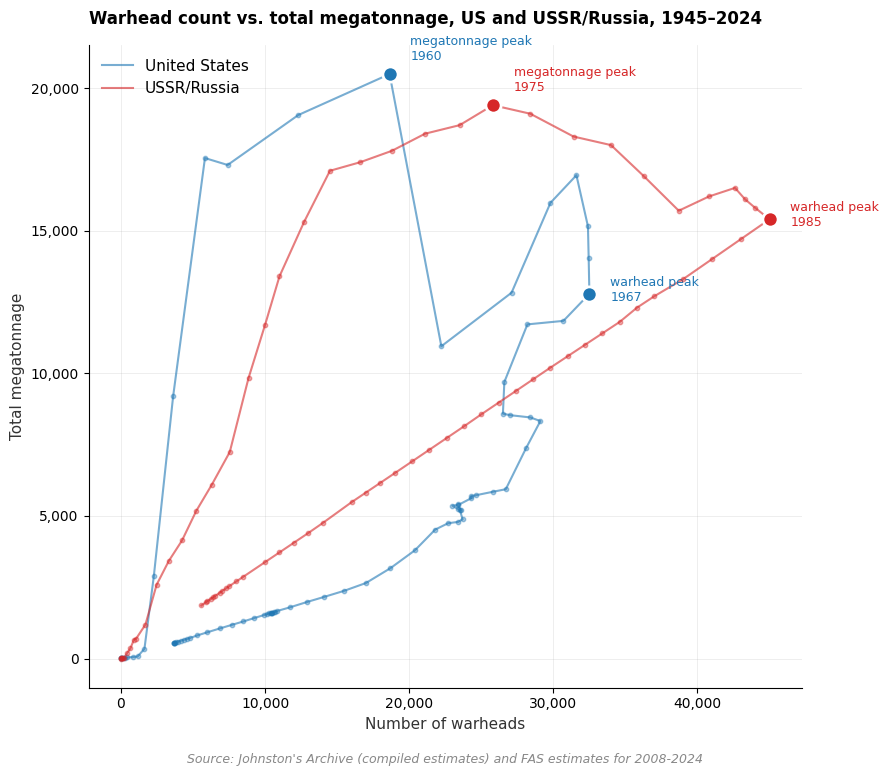

In [24]:
# Plot warhead count vs megatonnage, with year as the path

fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for country, color in [('United States', US_COLOR), ('USSR/Russia', RU_COLOR)]:
    sub = df[df['country'] == country].sort_values('year')

    # Path traced through time
    ax.plot(sub['warheads'], sub['megatons'], color=color, linewidth=1.5,
            alpha=0.6, zorder=2, label=country)
    ax.scatter(sub['warheads'], sub['megatons'], color=color, s=10,
               alpha=0.4, zorder=3)

    # Mark each peak with a labeled point
    warhead_peak_idx = sub['warheads'].idxmax()
    megaton_peak_idx = sub['megatons'].idxmax()
    wp = sub.loc[warhead_peak_idx]
    mp = sub.loc[megaton_peak_idx]

    ax.scatter([wp['warheads']], [wp['megatons']], color=color, s=120,
               edgecolor='white', linewidth=2, zorder=5)
    ax.annotate(f"warhead peak\n{int(wp['year'])}",
                xy=(wp['warheads'], wp['megatons']),
                xytext=(15, -5), textcoords='offset points',
                fontsize=9, color=color)

    ax.scatter([mp['warheads']], [mp['megatons']], color=color, s=120,
               edgecolor='white', linewidth=2, zorder=5)
    ax.annotate(f"megatonnage peak\n{int(mp['year'])}",
                xy=(mp['warheads'], mp['megatons']),
                xytext=(15, 10), textcoords='offset points',
                fontsize=9, color=color)

ax.legend(loc='upper left', frameon=False, fontsize=11)
ax.set_xlabel('Number of warheads', fontsize=11, color='#333')
ax.set_ylabel('Total megatonnage', fontsize=11, color='#333')

# Title now describes the date range and what the chart shows
ax.set_title('Warhead count vs. total megatonnage, US and USSR/Russia, 1945–2024',
             fontsize=12, fontweight='bold', loc='left', pad=15)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.text(0.5, 0.01, "Source: Johnston's Archive (compiled estimates) and FAS estimates for 2008-2024",
         fontsize=9, color='#888888', ha='center', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('trajectories.png', facecolor='white', dpi=150, bbox_inches='tight')
plt.show()

# Interpretations and conclusions

The data shows three things.

First, the world's total nuclear destructive capacity peaked years before warhead counts peaked. The United States held over 20,000 megatons of nuclear yield in 1960. From that point on, total US megatonnage fell almost every year, even as the warhead count continued climbing for another seven years. The Soviet Union followed a similar pattern with a delayed schedule: total megatonnage peaked in 1975, while the warhead count kept rising until 1985.

Second, the divergence between count and capability is documented but the data alone does not establish what caused it. Nuclear policy historians and analysts (including Kristensen and Norris at the Federation of American Scientists, and the National Academy of Sciences in its 1997 review of US nuclear policy) have proposed several technological explanations: improvements in missile accuracy that made very large yields unnecessary, the development of multiple independently targetable reentry vehicles (MIRVs) that allowed one missile to carry many smaller warheads, and a shift in nuclear doctrine away from city-targeting toward precision strikes against military targets. The data is consistent with these explanations but does not select among them.

Third, the post-Cold War reductions in warhead counts came from a different mechanism than the long-running megatonnage decline. SALT, START, SORT, and New START were bilateral treaties between the United States and the Soviet Union, and later Russia, that established caps on the number of strategic warheads each country could deploy and verification mechanisms — inspectors on both sides, regular data exchanges, transparency about deployments. These treaties counted warheads. They did not directly cap destructive yield.

In February 2026, New START expired without a successor. The two countries have informally agreed to keep observing the treaty's limits while they negotiate a replacement, but the arrangement is voluntary and not legally binding. For the first time since 1972, there is no formal cap on either country's strategic nuclear arsenal.

The data shown here describes what happened to the size and capability of US and Soviet/Russian nuclear arsenals from 1945 through 2024. It does not predict what comes next.

# Future directions

Several questions this project raises:

- **Other countries.** Johnston's Archive compiles similar warhead and megatonnage estimates for the UK, France, China, Israel, India, Pakistan, North Korea, and South Africa, but with sparser data. Adding these to the bubble chart would show their trajectories alongside the superpowers, though their combined arsenals never approach the scale of US or Russian capacity.
- **Average yield over time.** Plotting average yield per warhead (megatons divided by warheads) for each country would show the technological shift directly. Both countries' average yields have been falling since the early 1960s.
- **Equivalent megatonnage (EMt).** Megatonnage alone overstates the destructive impact of very large weapons. EMt is a scaling that compensates for the fact that smaller explosions cause proportionally more blast destruction per unit of yield. An EMt analysis would tell yet another story.
- **Deployed vs stockpiled.** The data here covers all warheads in the stockpile. Looking specifically at deployed warheads (those mounted on missiles or aircraft and ready to launch) would change the recent figures significantly, since modernization has shifted many warheads to reserve.

# Note on the video

The accompanying video is a roughly five-minute narrated walk-through of the analysis presented in this notebook. Its structure:

1. **Cold open (~30 seconds).** A short clip from the 1983 film *WarGames* — the well-known dialogue ending in "How about a nice game of chess? / Later. Let's play global thermonuclear war." The clip is used briefly to set the era and the cultural framing the title draws on.
2. **Frame at 1983 (~30 seconds).** The bubble chart is shown frozen at the year 1983 — the year *WarGames* was released — to introduce what the chart is encoding (warheads on the x-axis, total megatonnage on the log-scale y-axis, average yield as bubble size).
3. **Animated walk-through (~3 minutes).** The animation rewinds to 1945 and plays forward, with narration covering the early atomic period, the megaton-yield era of the 1950s, the divergence between megatonnage peaks (US 1960, USSR 1975) and warhead-count peaks (US 1967, USSR 1985), the post-Cold-War decline under SALT/START/SORT/New START, and the February 2026 expiration of New START.
4. **Closing (~45 seconds).** A montage from the end of *WarGames* — the WOPR computer running through every nuclear-war scenario, each ending in mutual destruction, before delivering the film's final line: "The only winning move is not to play." Brief closing narration follows, noting that the data describes what happened to the size and capability of US and Soviet/Russian arsenals from 1945 through 2024 but does not predict what comes next now that New START has expired without a successor.

## Media credits

The video incorporates the following third-party material:

- ***WarGames*** (dir. John Badham, MGM, 1983) — short dialogue clip in the cold open ("How about a nice game of chess? / Later. Let's play global thermonuclear war."), and a closing montage of the WOPR simulation sequence ending with the film's final line, "The only winning move is not to play" (which the project title draws on).

All third-party material is used briefly under fair use (17 U.S.C. § 107) for purposes of criticism, commentary, and educational analysis. No claim of ownership over any third-party material is made, and no commercial use is intended. The video is hosted as an unlisted YouTube link for class submission only.

# Acknowledgements

**Primary historical data source.** [Johnston's Archive: Nuclear Stockpile Estimates](https://www.johnstonsarchive.net/nuclear/nukestock.html), compiled by Wm. Robert Johnston (last modified 2007). Johnston reconciles estimates from the Natural Resources Defense Council Nuclear Weapons Databook (1984, 1989, 1994, 1995, 2000, 2002, 2006), Department of Energy declassified figures (1994), Wohlstetter's high/low/median estimates, and reports from senior US defense officials.

**Recent-year data sources.** [Federation of American Scientists Nuclear Notebook](https://thebulletin.org/nuclear-notebook/) (Kristensen, Korda, Norris, Johns, and Knight, 2024) for warhead counts after 2007. [SIPRI Yearbook 2025](https://www.sipri.org/yearbook/2025/06) for current arsenal figures and modernization trends. Megatonnage estimates for 2008-2024 are extrapolated based on documented average yield trends and weapon retirement schedules. [The Future of US Nuclear Weapons Policy](https://nap.nationalacademies.org/read/5796/chapter/8) (National Academy of Sciences, 1997) for context on the technological shift toward smaller, more accurate warheads.

**Post-treaty reporting.** Information about the February 2026 expiration of New START and the subsequent informal arrangement between the US and Russia comes from reporting by the Arms Control Association, the Council on Foreign Relations, NPR, PBS NewsHour, and Axios.

**Cultural reference and video media.** The accompanying video opens with a short clip from the 1983 film *WarGames* (directed by John Badham, MGM). See the *Note on the video* section above for a full description of how the clip is used and a fair-use statement.

**Visualization style.** The bubble chart animation is inspired by the work of Hans Rosling.

**AI assistance.** This project was developed with help from two AI tools. Anthropic's Claude was used for iterative discussion of narrative framing, data visualization design, animation logic, and writing assistance. Google's Gemini (built into Colab) was used for code generation and notebook editing. All analytical decisions, final narrative choices, and interpretations of the data are my own.

**Thanks.** To Professor Jeremy Manning and PSYC 81.09 (Storytelling with Data) at Dartmouth College.